In [1]:
# Medical Data Analysis & Prediction Project
# End-to-End Notebook with Visualization & Storytelling

# =============================
# 1. Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [2]:
# =============================
# 2. Load Data
# =============================
df = pd.read_csv('/kaggle/input/datasets/prasad22/healthcare-dataset/healthcare_dataset.csv')
df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
# =============================
# 3. Data Preparation
# =============================
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['LOS'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Age grouping (clinically meaningful segmentation)
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 65:
        return 'Adult'
    else:
        return 'Senior'

df['Age Group'] = df['Age'].apply(age_group)




In [4]:
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 65:
        return 'Adult'
    else:
        return 'Senior'

df['Age Group'] = df['Age'].apply(age_group)

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,LOS,Age Group
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,Adult
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,Adult
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,Senior
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,Adult
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,Adult


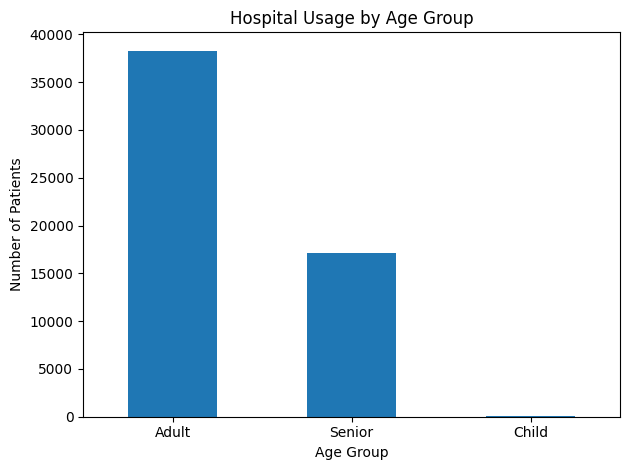

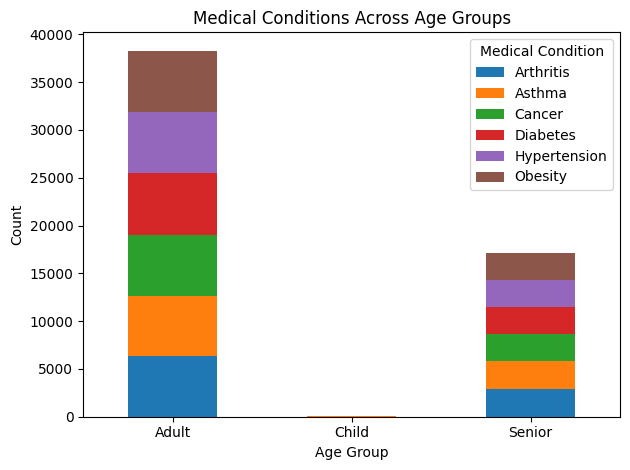

In [5]:
# =============================
# 4. Exploratory Data Analysis + Storytelling
# =============================

# --- Story 1: Who dominates hospital usage? ---

age_counts = df['Age Group'].value_counts()
age_counts.plot(kind='bar')
plt.title('Hospital Usage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --- Story 2: What conditions affect each age group? ---

age_condition = df.groupby(['Age Group', 'Medical Condition']).size().unstack(fill_value=0)
age_condition.plot(kind='bar', stacked=True)
plt.title('Medical Conditions Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

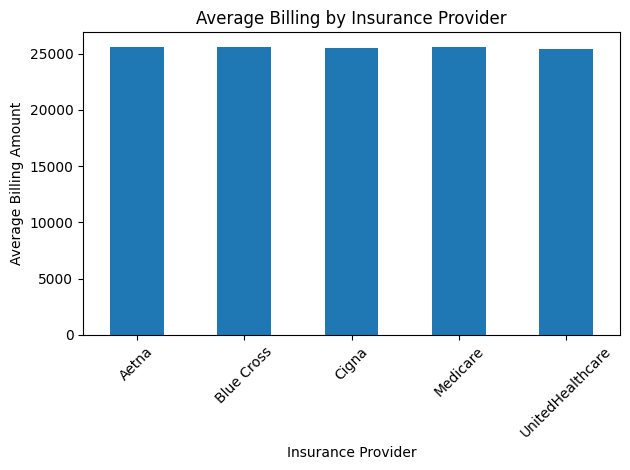

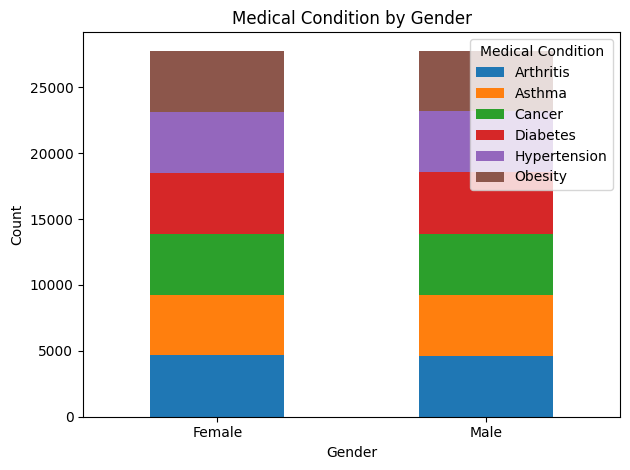

In [6]:
# =============================
# --- Story 3: Financial Burden (Insurance vs Billing) ---
# =============================

insurance_cost = df.groupby('Insurance Provider')['Billing Amount'].mean()
insurance_cost.plot(kind='bar')
plt.title('Average Billing by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# =============================
# --- Story 5: Gender and Disease Patterns ---
# =============================

gender_condition = df.groupby(['Gender', 'Medical Condition']).size().unstack(fill_value=0)
gender_condition.plot(kind='bar', stacked=True)
plt.title('Medical Condition by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

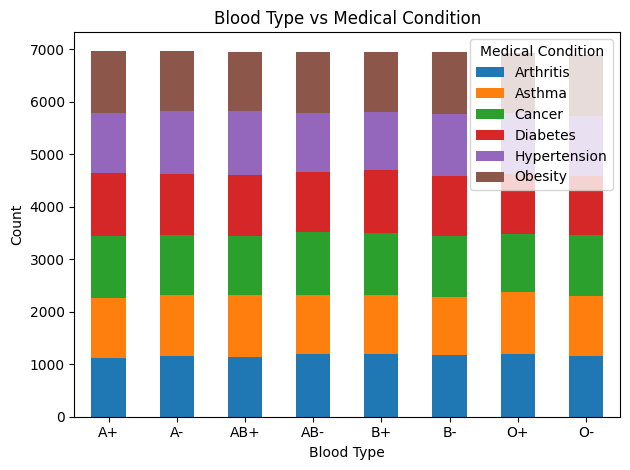

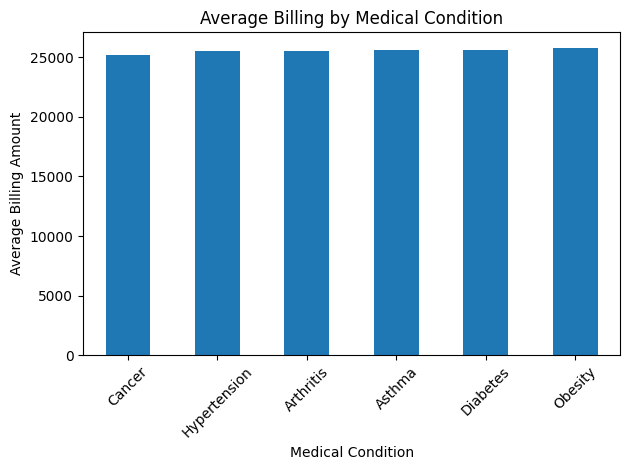

In [7]:
# =============================
# --- Story 6: Blood Type vs Medical Condition ---
# =============================

blood_condition = df.groupby(['Blood Type', 'Medical Condition']).size().unstack(fill_value=0)
blood_condition.plot(kind='bar', stacked=True)
plt.title('Blood Type vs Medical Condition')
plt.xlabel('Blood Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# =============================
# --- Story 7: Cost vs Condition ---
# =============================

condition_cost = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values()
condition_cost.plot(kind='bar')
plt.title('Average Billing by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =============================
# Interpretation Notes
# =============================
# - Insurance plot: identifies cost differences across providers
# - Hospital plot: reveals operational or specialization-driven cost variation
# - Gender plot: highlights demographic distribution of conditions
# - Blood type plot: mostly exploratory (non-causal relationships expected)
# - Condition cost plot: identifies high-cost conditions for planning


In [8]:
# =============================
# 5. Prediction Task
# =============================
# Predict Medical Condition (note: consider removing Test Results to avoid leakage)

features = ['Age', 'Gender', 'Blood Type', 'Test Results']
target = 'Medical Condition'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# =============================
# 6. Preprocessing
# =============================

num_cols = ['Age']
cat_cols = ['Gender', 'Blood Type', 'Test Results']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


In [10]:
# =============================
# 7. Models
# =============================

# --- Random Forest Model ---
rf_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train Random Forest
rf_model.fit(X_train, y_train)


# --- Logistic Regression Model (Baseline) ---
lr_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Train Logistic Regression
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Blood Type',
                                                   'Test Results'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [11]:
# Predictions
rf_preds = rf_model.predict(X_test)
lr_preds = lr_model.predict(X_test)

# Evaluation
print("Random Forest Results:")
print(classification_report(y_test, rf_preds))

print("Logistic Regression Results:")
print(classification_report(y_test, lr_preds))

Random Forest Results:
              precision    recall  f1-score   support

   Arthritis       0.16      0.15      0.15      1915
      Asthma       0.17      0.18      0.17      1847
      Cancer       0.17      0.15      0.16      1871
    Diabetes       0.17      0.18      0.18      1822
Hypertension       0.17      0.18      0.18      1788
     Obesity       0.17      0.17      0.17      1857

    accuracy                           0.17     11100
   macro avg       0.17      0.17      0.17     11100
weighted avg       0.17      0.17      0.17     11100

Logistic Regression Results:
              precision    recall  f1-score   support

   Arthritis       0.16      0.20      0.18      1915
      Asthma       0.17      0.09      0.12      1847
      Cancer       0.18      0.04      0.07      1871
    Diabetes       0.17      0.17      0.17      1822
Hypertension       0.16      0.31      0.22      1788
     Obesity       0.16      0.17      0.17      1857

    accuracy             

In [12]:

# =============================
# 9. Advanced Visualizations (Including 3D)
# =============================

from mpl_toolkits.mplot3d import Axes3D

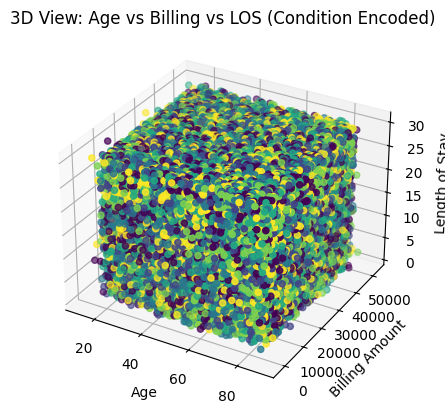

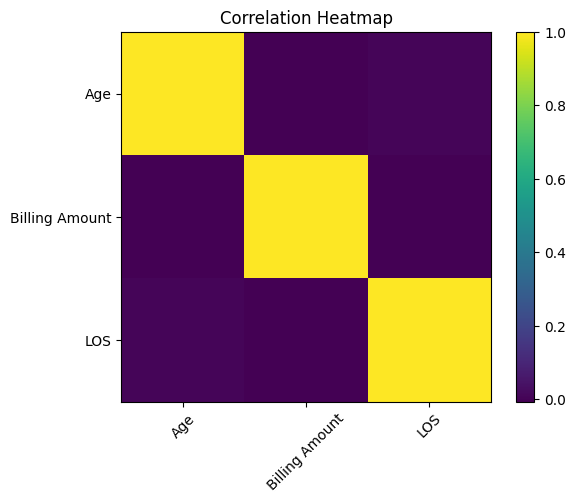

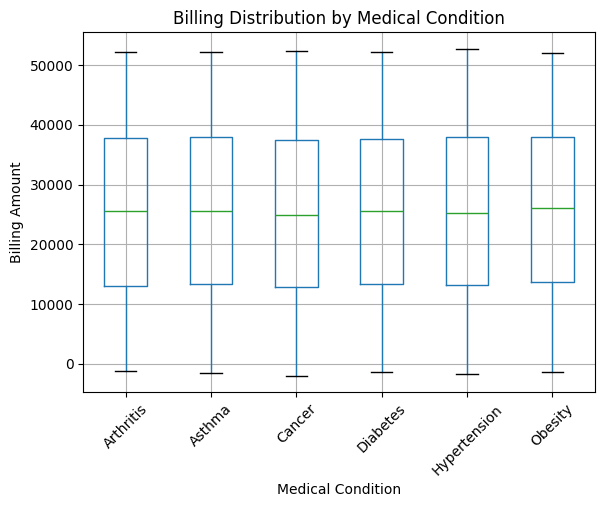

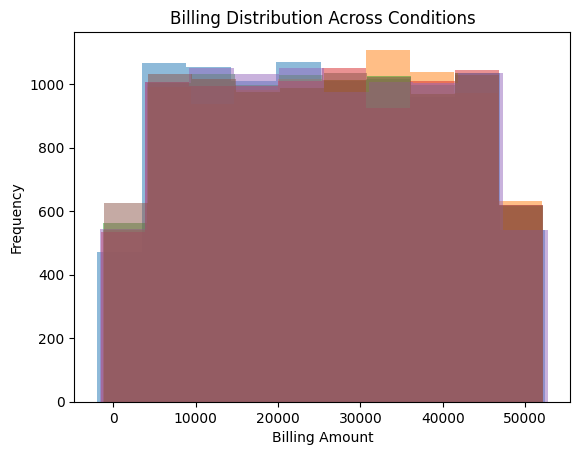

In [13]:
# --- 3D Visualization: Age, Billing, LOS vs Condition ---

# Ensure LOS exists
# df['LOS'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Encode Medical Condition as numeric for plotting
condition_codes = df['Medical Condition'].astype('category').cat.codes

ax.scatter(df['Age'], df['Billing Amount'], df['LOS'], c=condition_codes)
ax.set_xlabel('Age')
ax.set_ylabel('Billing Amount')
ax.set_zlabel('Length of Stay')
plt.title('3D View: Age vs Billing vs LOS (Condition Encoded)')
plt.show()


# --- Correlation Heatmap (Numerical Insight) ---

corr = df[['Age', 'Billing Amount', 'LOS']].corr()

plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.colorbar()
plt.show()


# --- Boxplot: Billing Distribution by Medical Condition ---

df.boxplot(column='Billing Amount', by='Medical Condition')
plt.title('Billing Distribution by Medical Condition')
plt.suptitle('')
plt.xticks(rotation=45)
plt.ylabel('Billing Amount')
plt.show()


# --- Violin-like Insight using Histogram Overlay ---

for condition in df['Medical Condition'].unique():
    subset = df[df['Medical Condition'] == condition]
    plt.hist(subset['Billing Amount'], alpha=0.5)

plt.title('Billing Distribution Across Conditions')
plt.xlabel('Billing Amount')
plt.ylabel('Frequency')
plt.show()



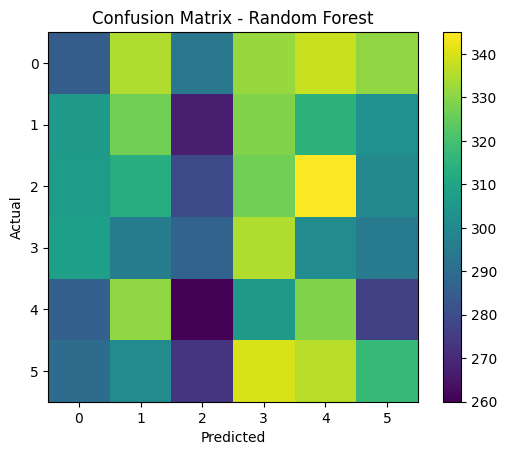

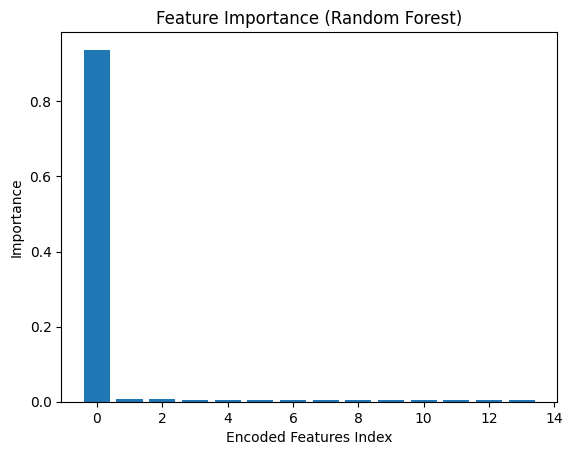

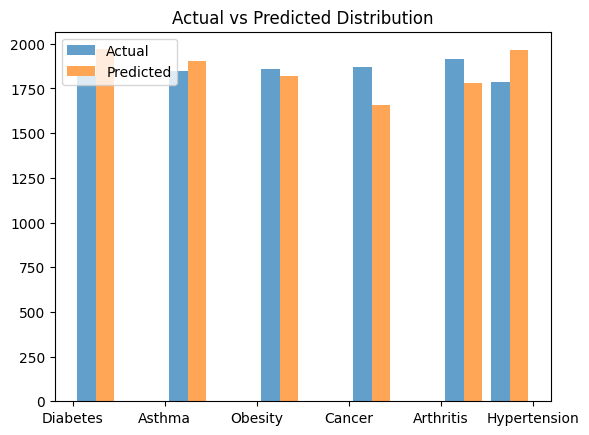

In [14]:
# =============================
# 10. Model Evaluation Visualizations
# =============================

from sklearn.metrics import confusion_matrix
import numpy as np

# --- Confusion Matrix (Random Forest) ---
rf_preds = rf_model.predict(X_test)
cm = confusion_matrix(y_test, rf_preds)

plt.imshow(cm)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()


# --- Feature Importance (Random Forest) ---
# Get feature names after preprocessing (approximation)
rf_clf = rf_model.named_steps['model']

importances = rf_clf.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Encoded Features Index')
plt.ylabel('Importance')
plt.show()


# --- Optional: Prediction Distribution ---
plt.hist([y_test, rf_preds], label=['Actual', 'Predicted'], alpha=0.7)
plt.title('Actual vs Predicted Distribution')
plt.legend()
plt.show() 

In [15]:
# =============================
# 9. Storytelling Summary
# =============================

# Key Narrative:
# 1. Hospitals are dominated by [Age Group] → resource allocation insight
# 2. Chronic diseases increase with age → preventive care importance
# 3. Billing varies significantly across hospitals → inefficiency signal
# 4. Certain conditions drive the majority of costs → optimization target
# 5. Model can assist in early classification but NOT diagnosis

# =============================
# END
# =============================
